# Combined indicator

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [453]:
import ocha_stratus as stratus
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import LeaveOneOut

from src.constants import *

In [3]:
blob_name = f"{PROJECT_PREFIX}/processed/iri_cerf_stats.parquet"
df_stats_iri = stratus.load_parquet_from_blob(blob_name)

In [4]:
df_stats_iri

,year,Jan,Feb,Mar,Apr,May,Jun,Humanitarian Bad Years (rank),EM-DAT Bad Years,CHIRPS Precip JAS (mm),emdat_float,Amount in US$
0,1991,29.4,31.0,31.9,32.6,30.5,42.3,16.0,None,62.1,0.0,NaN
1,1992,30.0,41.7,38.5,46.7,39.3,40.1,16.0,None,53.4,0.0,NaN
2,1993,32.6,37.6,33.9,37.2,38.3,47.5,16.0,None,70.4,0.0,NaN
3,1994,32.3,32.8,35.3,42.0,43.8,39.4,16.0,None,80.7,0.0,NaN
4,1995,33.7,31.6,24.5,30.8,31.3,27.2,16.0,None,91.1,0.0,NaN
5,1996,37.6,39.3,34.1,43.2,31.6,33.0,16.0,None,60.7,0.0,NaN
6,1997,34.2,39.6,42.4,28.9,36.1,41.3,16.0,None,71.2,0.0,NaN
7,1998,32.8,26.8,33.0,25.8,30.6,27.5,16.0,None,85.0,0.0,NaN
8,1999,36.3,31.3,35.8,40.3,27.5,25.7,30.0,None,99.1,0.0,NaN
9,2000,36.1,32.9,32.5,27.7,35.4,28.0,16.0,None,76.7,0.0,NaN


In [5]:
blob_name = (
    f"{PROJECT_PREFIX}/processed/chirps/chirps_dek_season_cumul.parquet"
)
df_chirps_raw = stratus.load_parquet_from_blob(blob_name)

In [6]:
blob_name = f"{PROJECT_PREFIX}/processed/asi/mrt_asi_dekadal.parquet"
df_asi_raw = stratus.load_parquet_from_blob(blob_name)

<Axes: xlabel='asi_all'>

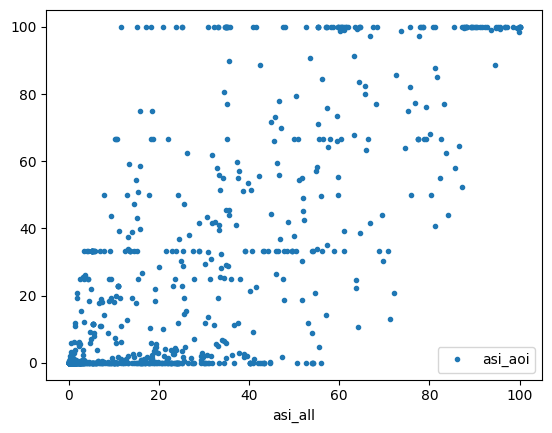

In [7]:
df_asi_raw.plot(x="asi_all", y="asi_aoi", linewidth=0, marker=".")

In [8]:
df_dek = df_chirps_raw.merge(df_asi_raw)
df_dek = df_dek.drop(columns=["Year", "Month", "Dekad"])

In [9]:
min_year, max_year = 1991, 2024
total_years = max_year - min_year + 1

In [10]:
df_dek_limit_years = df_dek[
    df_dek["year"].isin(range(min_year, max_year + 1))
].copy()

In [11]:
geos = ["all", "aoi"]
ind_cols = [f"rfh_{x}_cumul" for x in geos] + [f"asi_{x}" for x in geos]

In [14]:
flip_cols = [x for x in ind_cols if "rfh" in x]

In [15]:
flip_cols

['rfh_all_cumul', 'rfh_aoi_cumul']

In [17]:
for col in ind_cols:
    flip = -1 if col in flip_cols else 1
    df_dek_limit_years[f"{col}_norm"] = flip * df_dek_limit_years.groupby(
        "dekad_overall"
    )[col].transform(lambda x: (x - x.mean()) / x.std())

In [26]:
df_stats_iri["hum_bad_aligned"] = -df_stats_iri[
    "Humanitarian Bad Years (rank)"
]
df_stats_iri["cerf_aligned"] = df_stats_iri["Amount in US$"]

In [27]:
for col in ["hum_bad_aligned", "cerf_aligned"]:
    df_stats_iri[f"{col}_norm"] = (
        df_stats_iri[col] - df_stats_iri[col].mean()
    ) / df_stats_iri[col].std()

In [28]:
rp_overall_target = 4
n_years_overall_target = int((max_year - min_year + 1 + 1) / rp_overall_target)

In [739]:
n_years_overall_target

8

In [740]:
(max_year - min_year + 1 + 1) / n_years_overall_target

4.375

In [812]:
max_badyear_target = df_stats_iri.sort_values(
    "Humanitarian Bad Years (rank)"
).iloc[n_years_overall_target - 1]["Humanitarian Bad Years (rank)"]

In [813]:
max_badyear_target

np.float64(12.0)

In [814]:
# max_badyear_target = 8

In [815]:
df_stats_iri["target"] = (
    df_stats_iri["Humanitarian Bad Years (rank)"] <= max_badyear_target
)

In [816]:
df_stats_iri[
    (df_stats_iri["Amount in US$"] > 0) & ~df_stats_iri["target_bad_years"]
]

,year,Jan,Feb,Mar,Apr,May,Jun,Humanitarian Bad Years (rank),EM-DAT Bad Years,CHIRPS Precip JAS (mm),emdat_float,Amount in US$,hum_bad,cerf_aligned,hum_bad_aligned,hum_bad_aligned_norm,cerf_aligned_norm,target,target_bad_years,target_bad_years_revised
17,2008,35.9,31.3,28.7,26.7,30.4,29.4,16.0,None,83.7,0.0,2174497.0,-16.0,2174497.0,-16.0,0.191937,0.97747,False,False,False
18,2009,32.3,30.6,31.5,35.4,39.3,37.3,30.0,None,87.1,0.0,1751722.0,-30.0,1751722.0,-30.0,-1.469192,0.67246,False,False,False


In [817]:
df_stats_iri["Amount in US$"].unique()

array([     nan, 1132595., 2174497., 1751722.,       0., 4005971.,
       2532163., 3975873.])

In [818]:
# threshold for targeting revised upwards so that CERF years can be targeted too
max_revised_badyear_target = df_stats_iri.sort_values(
    "Humanitarian Bad Years (rank)"
).iloc[n_years_overall_target - 1 - 2]["Humanitarian Bad Years (rank)"]

In [819]:
df_stats_iri["target_bad_years_revised"] = (
    df_stats_iri["Humanitarian Bad Years (rank)"] <= max_revised_badyear_target
)

In [820]:
df_stats_iri["target"] = df_stats_iri["target_bad_years_revised"] | (
    (df_stats_iri["Amount in US$"] > 0)
    & (df_stats_iri["Humanitarian Bad Years (rank)"] <= 16)
)

In [821]:
df_stats_iri["target"].sum()

np.int64(8)

In [822]:
(max_year - min_year + 1 + 1) / df_stats_iri["target"].sum()

np.float64(4.375)

In [823]:
df_stats_iri[["year", "Amount in US$", "target"]]

,year,Amount in US$,target
0,1991,NaN,False
1,1992,NaN,False
2,1993,NaN,False
3,1994,NaN,False
4,1995,NaN,False
5,1996,NaN,False
6,1997,NaN,False
7,1998,NaN,False
8,1999,NaN,False
9,2000,NaN,False


In [824]:
df_dek_compare = df_dek_limit_years.merge(df_stats_iri)

In [877]:
df_dek_compare.columns

Index(['date', 'rfh_all', 'rfh_aoi', 'year', 'rfh_all_cumul', 'rfh_aoi_cumul',
       'dekad', 'dekad_overall', 'asi_all', 'asi_aoi', 'rfh_all_cumul_norm',
       'rfh_aoi_cumul_norm', 'asi_all_norm', 'asi_aoi_norm', 'Jan', 'Feb',
       'Mar', 'Apr', 'May', 'Jun', 'Humanitarian Bad Years (rank)',
       'EM-DAT Bad Years', 'CHIRPS Precip JAS (mm)', 'emdat_float',
       'Amount in US$', 'hum_bad', 'cerf_aligned', 'hum_bad_aligned',
       'hum_bad_aligned_norm', 'cerf_aligned_norm', 'target',
       'target_bad_years', 'target_bad_years_revised',
       'hum_bad_aligned_norm_reg', 'hum_bad_aligned_norm_single_reg',
       'hum_bad_aligned_norm_reg_loocv', 'target_logreg_loocv',
       'target_logreg'],
      dtype='object')

In [825]:
ind_norm_cols = [f"{x}_norm" for x in ind_cols]

In [878]:
ind_norm_cols

['rfh_all_cumul_norm', 'rfh_aoi_cumul_norm', 'asi_all_norm', 'asi_aoi_norm']

In [826]:
ind_norm_all_cols = [x for x in ind_norm_cols if "all" in x]

In [827]:
target_col = "hum_bad_aligned_norm"

for dekad, group in df_dek_compare.groupby("dekad_overall"):
    X = group[ind_norm_all_cols]
    # X = sm.add_constant(X)  # adds intercept
    y = group[target_col]

    model = sm.OLS(y, X).fit()
    print(model.summary())  # nicely formatted regression output

    # Predicted values:
    y_pred = model.predict(X)

    df_dek_compare.loc[group.index, f"{target_col}_reg"] = y_pred

                                  OLS Regression Results                                 
Dep. Variable:     hum_bad_aligned_norm   R-squared (uncentered):                   0.189
Model:                              OLS   Adj. R-squared (uncentered):              0.138
Method:                   Least Squares   F-statistic:                              3.732
Date:                  Sun, 08 Feb 2026   Prob (F-statistic):                      0.0349
Time:                          14:04:20   Log-Likelihood:                         -44.172
No. Observations:                    34   AIC:                                      92.34
Df Residuals:                        32   BIC:                                      95.40
Df Model:                             2                                                  
Covariance Type:              nonrobust                                                  
                         coef    std err          t      P>|t|      [0.025      0.975]
-------------

In [828]:
X = df_dek_compare[ind_norm_all_cols]
# X = sm.add_constant(X)  # adds intercept
y = df_dek_compare[target_col]

model = sm.OLS(y, X).fit()
print(model.summary())  # nicely formatted regression output

# Predicted values:
y_pred = model.predict(X)

df_dek_compare[f"{target_col}_single_reg"] = y_pred

                                  OLS Regression Results                                 
Dep. Variable:     hum_bad_aligned_norm   R-squared (uncentered):                   0.329
Model:                              OLS   Adj. R-squared (uncentered):              0.324
Method:                   Least Squares   F-statistic:                              74.49
Date:                  Sun, 08 Feb 2026   Prob (F-statistic):                    4.72e-27
Time:                          14:04:20   Log-Likelihood:                         -368.61
No. Observations:                   306   AIC:                                      741.2
Df Residuals:                       304   BIC:                                      748.7
Df Model:                             2                                                  
Covariance Type:              nonrobust                                                  
                         coef    std err          t      P>|t|      [0.025      0.975]
-------------

In [875]:
df_corr = (
    df_dek_compare.groupby("dekad_overall")
    .corr(numeric_only=True)
    .reset_index()
    .rename(columns={"level_1": "variable"})
)

In [830]:
ind_norm_all_cols

['rfh_all_cumul_norm', 'asi_all_norm']

In [831]:
ind_norm_all_cols

['rfh_all_cumul_norm', 'asi_all_norm']

In [832]:
target_col

'hum_bad_aligned_norm'

In [833]:
df_dek_compare

,date,rfh_all,rfh_aoi,year,rfh_all_cumul,rfh_aoi_cumul,dekad,dekad_overall,asi_all,asi_aoi,...,hum_bad,cerf_aligned,hum_bad_aligned,hum_bad_aligned_norm,cerf_aligned_norm,target,target_bad_years,target_bad_years_revised,hum_bad_aligned_norm_reg,hum_bad_aligned_norm_single_reg
0,1991-07-01,5.617332,18.406073,1991,5.617332,18.406073,1,19,83.679592,62.572163,...,-16.0,NaN,-16.0,0.191937,NaN,False,False,False,0.405680,0.010647
1,1991-07-11,3.912060,15.553448,1991,9.529392,33.959520,2,20,65.837166,63.452788,...,-16.0,NaN,-16.0,0.191937,NaN,False,False,False,0.551452,0.438665
2,1991-07-21,6.490611,18.647058,1991,16.020003,52.606578,3,21,37.873673,57.112503,...,-16.0,NaN,-16.0,0.191937,NaN,False,False,False,0.610667,0.475580
3,1991-08-01,4.910419,17.289690,1991,20.930421,69.896268,1,22,37.662681,54.866114,...,-16.0,NaN,-16.0,0.191937,NaN,False,False,False,0.718406,0.720957
4,1991-08-11,10.776464,49.020874,1991,31.706886,118.917142,2,23,42.288469,55.729734,...,-16.0,NaN,-16.0,0.191937,NaN,False,False,False,0.753904,0.712554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,2024-08-11,12.699847,33.545225,2024,41.301433,149.721697,2,23,0.713157,0.000000,...,-30.0,0.0,-30.0,-1.469192,-0.591314,False,False,False,-0.379685,-0.368247
302,2024-08-21,10.283822,42.637570,2024,51.585255,192.359267,3,24,1.118828,0.642633,...,-30.0,0.0,-30.0,-1.469192,-0.591314,False,False,False,-0.162938,-0.192913
303,2024-09-01,13.865711,45.931057,2024,65.450967,238.290323,1,25,1.664252,0.107234,...,-30.0,0.0,-30.0,-1.469192,-0.591314,False,False,False,-0.315539,-0.318885
304,2024-09-11,15.108276,49.688804,2024,80.559243,287.979128,2,26,1.308534,0.000000,...,-30.0,0.0,-30.0,-1.469192,-0.591314,False,False,False,-0.628807,-0.532699


In [834]:
target_col = "hum_bad_aligned_norm"
pred_col = f"{target_col}_reg_loocv"
df_dek_compare[pred_col] = np.nan

loo = LeaveOneOut()

for dekad, group in df_dek_compare.groupby("dekad_overall"):
    X = group[ind_norm_all_cols].values
    y = group[target_col].values

    preds = np.zeros(len(group))

    for train_idx, test_idx in loo.split(X):
        model = LinearRegression()
        model.fit(X[train_idx], y[train_idx])
        preds[test_idx] = model.predict(X[test_idx])

    df_dek_compare.loc[group.index, pred_col] = preds

In [835]:
target_col = "target"
pred_col = f"{target_col}_logreg_loocv"
df_dek_compare[pred_col] = np.nan

loo = LeaveOneOut()

for dekad, group in df_dek_compare.groupby("dekad_overall"):
    X = group[ind_norm_all_cols].values
    y = group[target_col].values

    preds = np.zeros(len(group))

    for train_idx, test_idx in loo.split(X):
        model = LogisticRegression(
            solver="liblinear",  # robust for small samples
            max_iter=1000,
        )
        model.fit(X[train_idx], y[train_idx])

        # probability of class == 1
        preds[test_idx] = model.predict_proba(X[test_idx])[:, 1]

    df_dek_compare.loc[group.index, pred_col] = preds

In [836]:
target_col = "target"
pred_col = f"{target_col}_logreg"
df_dek_compare[pred_col] = np.nan

for dekad, group in df_dek_compare.groupby("dekad_overall"):
    X = group[ind_norm_all_cols].values
    y = group[target_col].values

    # guard: logistic regression needs at least two classes
    if len(np.unique(y)) < 2:
        continue

    model = LogisticRegression(
        solver="liblinear",
        max_iter=1000,
    )
    model.fit(X, y)

    # predicted probability of class == 1
    preds = model.predict_proba(X)[:, 1]

    df_dek_compare.loc[group.index, pred_col] = preds

In [874]:
df_dek_compare

,date,rfh_all,rfh_aoi,year,rfh_all_cumul,rfh_aoi_cumul,dekad,dekad_overall,asi_all,asi_aoi,...,hum_bad_aligned_norm,cerf_aligned_norm,target,target_bad_years,target_bad_years_revised,hum_bad_aligned_norm_reg,hum_bad_aligned_norm_single_reg,hum_bad_aligned_norm_reg_loocv,target_logreg_loocv,target_logreg
0,1991-07-01,5.617332,18.406073,1991,5.617332,18.406073,1,19,83.679592,62.572163,...,0.191937,NaN,False,False,False,0.405680,0.010647,0.449312,0.191104,0.167307
1,1991-07-11,3.912060,15.553448,1991,9.529392,33.959520,2,20,65.837166,63.452788,...,0.191937,NaN,False,False,False,0.551452,0.438665,0.616424,0.421284,0.361537
2,1991-07-21,6.490611,18.647058,1991,16.020003,52.606578,3,21,37.873673,57.112503,...,0.191937,NaN,False,False,False,0.610667,0.475580,0.656141,0.475050,0.428097
3,1991-08-01,4.910419,17.289690,1991,20.930421,69.896268,1,22,37.662681,54.866114,...,0.191937,NaN,False,False,False,0.718406,0.720957,0.767019,0.581141,0.528952
4,1991-08-11,10.776464,49.020874,1991,31.706886,118.917142,2,23,42.288469,55.729734,...,0.191937,NaN,False,False,False,0.753904,0.712554,0.827170,0.605672,0.531153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,2024-08-11,12.699847,33.545225,2024,41.301433,149.721697,2,23,0.713157,0.000000,...,-1.469192,-0.591314,False,False,False,-0.379685,-0.368247,-0.326371,0.149375,0.143774
302,2024-08-21,10.283822,42.637570,2024,51.585255,192.359267,3,24,1.118828,0.642633,...,-1.469192,-0.591314,False,False,False,-0.162938,-0.192913,-0.103305,0.201060,0.193894
303,2024-09-01,13.865711,45.931057,2024,65.450967,238.290323,1,25,1.664252,0.107234,...,-1.469192,-0.591314,False,False,False,-0.315539,-0.318885,-0.267517,0.167748,0.161197
304,2024-09-11,15.108276,49.688804,2024,80.559243,287.979128,2,26,1.308534,0.000000,...,-1.469192,-0.591314,False,False,False,-0.628807,-0.532699,-0.579453,0.124057,0.118109


In [870]:
df_corr = (
    df_dek_compare.groupby("dekad_overall")
    .corr(numeric_only=True)
    .reset_index()
    .rename(columns={"level_1": "variable"})
)

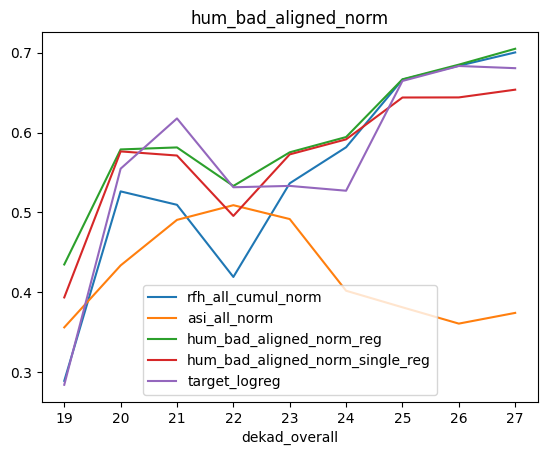

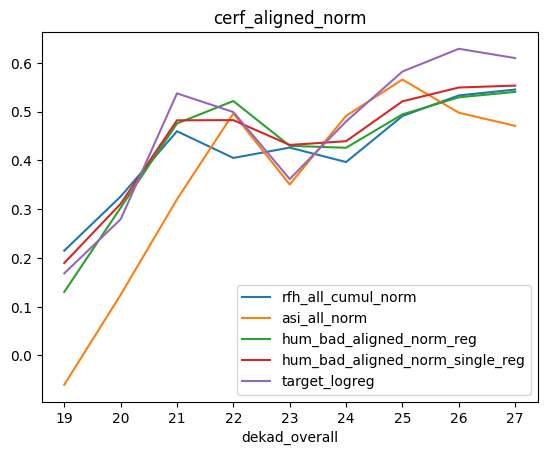

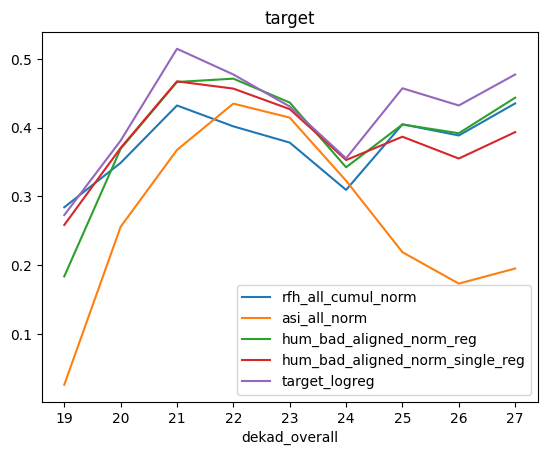

In [871]:
for target_col in ["hum_bad_aligned_norm", "cerf_aligned_norm", "target"]:
    fig, ax = plt.subplots()
    df_corr[df_corr["variable"] == target_col].set_index("dekad_overall")[
        ind_norm_all_cols
        + [
            "hum_bad_aligned_norm_reg",
            "hum_bad_aligned_norm_single_reg",
            "target_logreg",
        ]
    ].plot(ax=ax)
    ax.set_title(target_col)

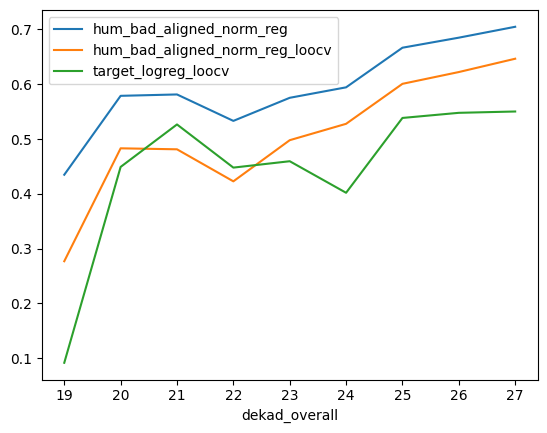

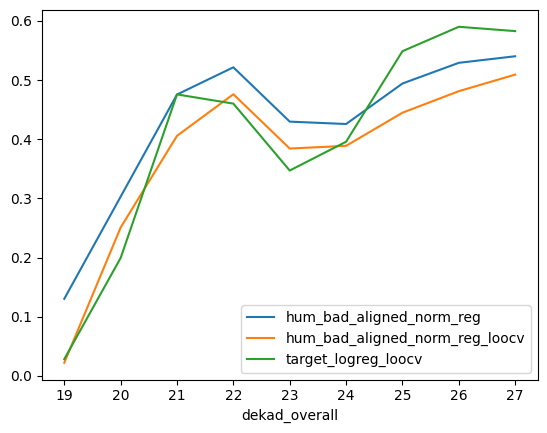

In [872]:
for target_col in ["hum_bad_aligned_norm", "cerf_aligned_norm"]:
    df_corr[df_corr["variable"] == target_col].set_index("dekad_overall")[
        [
            "hum_bad_aligned_norm_reg",
            "hum_bad_aligned_norm_reg_loocv",
            "target_logreg_loocv",
        ]
    ].plot()

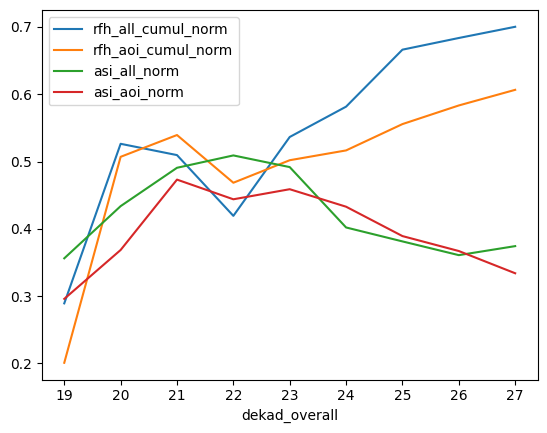

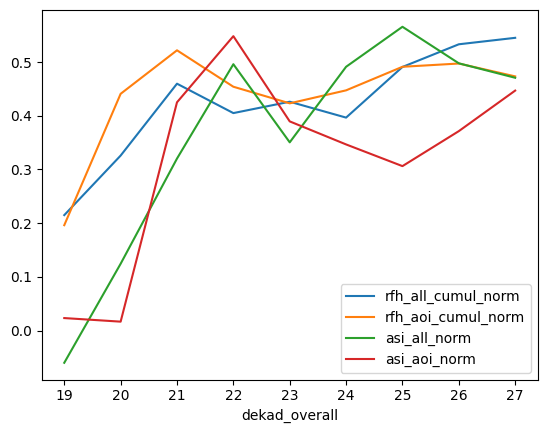

In [881]:
for target_col in ["hum_bad_aligned_norm", "cerf_aligned_norm"]:
    df_corr[df_corr["variable"] == target_col].set_index("dekad_overall")[
        ind_norm_cols
    ].plot()

In [841]:
pred_col

'target_logreg'

In [842]:
# reg_col = "hum_bad_aligned_norm_reg_loocv"
reg_col = "target_logreg_loocv"

overall_dicts = []
overall_dfs = []

for single_nyears_target in range(1, total_years):
    # if single_nyears_target != 4:
    #     continue
    print(single_nyears_target)

    # first calculate the triggers for each dekad
    # using the overall target RP
    dicts = []
    for dekad, group in df_dek_compare.groupby("dekad_overall"):
        thresh = group.sort_values(reg_col, ascending=False).iloc[
            single_nyears_target - 1
        ][reg_col]

        group["trigger_flat"] = group[reg_col] >= thresh

        pp = group["trigger_flat"]
        p = group["target"]
        tp = pp & p
        ppv = tp.sum() / pp.sum()
        tpr = tp.sum() / pp.sum()
        # print(group["trigger_flat"].sum())
        dicts.append({"dekad": dekad, "ppv": ppv})

    df_ppv = pd.DataFrame(dicts)

    # see what the best possible PPV is
    best_ppv = df_ppv["ppv"].max()

    # then iterate over dekads and keep increasing the threshold
    # until they have the same PPV as the best possible PPV
    dicts = []
    trig_years = []
    dfs = []
    for dekad, group in df_dek_compare.groupby("dekad_overall"):
        nyears_thresh = single_nyears_target + 1
        ppv = 0
        while ppv < best_ppv and nyears_thresh > 0:
            nyears_thresh -= 1
            if nyears_thresh == 0:
                group["trigger_revised"] = False
            else:
                thresh = group.sort_values(reg_col, ascending=False).iloc[
                    nyears_thresh - 1
                ][reg_col]
                group["trigger_revised"] = group[reg_col] >= thresh

            pp = group["trigger_revised"]
            p = group["target"]
            tp = pp & p
            ppv = tp.sum() / pp.sum()

        trig_years.extend(group[pp]["year"].unique())
        dfs.append(group[["dekad_overall", "year", "trigger_revised"]])
        dicts.append({"dekad": dekad, "n_years_thresh": nyears_thresh})

    df_out = pd.concat(dfs, ignore_index=True)

    df_threshs = pd.DataFrame(dicts)
    # display(df_threshs)
    trig_years = sorted({int(x) for x in trig_years})

    overall_rp = (total_years + 1) / len(trig_years)

    overall_p = df_stats_iri["target"]
    overall_pp = df_stats_iri["year"].isin(trig_years)

    overall_tp = overall_pp & overall_p
    overall_ppv = overall_tp.sum() / overall_pp.sum()
    overall_tpr = overall_tp.sum() / overall_p.sum()
    overall_f1 = 2 * overall_ppv * overall_tpr / (overall_ppv + overall_tpr)

    df_out["rp"] = overall_rp
    overall_dfs.append(df_out)

    overall_dicts.append(
        {
            "single_nyears_target": single_nyears_target,
            "best_ppv": best_ppv,
            "overall_rp": overall_rp,
            "overall_f1": overall_f1,
        }
    )

df_opt_trigger_years = pd.concat(overall_dfs, ignore_index=True)
df_opt_metrics = pd.DataFrame(overall_dicts)

1
2
3
4
5
6
7
8
9
10
11
12


/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_14715/4214597805.py:56: RuntimeWarning: invalid value encountered in scalar divide
  ppv = tp.sum() / pp.sum()
/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_14715/4214597805.py:56: RuntimeWarning: invalid value encountered in scalar divide
  ppv = tp.sum() / pp.sum()
/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_14715/4214597805.py:56: RuntimeWarning: invalid value encountered in scalar divide
  ppv = tp.sum() / pp.sum()
/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_14715/4214597805.py:56: RuntimeWarning: invalid value encountered in scalar divide
  ppv = tp.sum() / pp.sum()
/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_14715/4214597805.py:56: RuntimeWarning: invalid value encountered in scalar divide
  ppv = tp.sum() / pp.sum()
/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_14715/4214597805.py:56: RuntimeWarning: invalid value encountered in scalar divide
  ppv = 

13
14
15
16
17
18
19
20
21
22
23
24


/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_14715/4214597805.py:56: RuntimeWarning: invalid value encountered in scalar divide
  ppv = tp.sum() / pp.sum()
/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_14715/4214597805.py:56: RuntimeWarning: invalid value encountered in scalar divide
  ppv = tp.sum() / pp.sum()
/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_14715/4214597805.py:56: RuntimeWarning: invalid value encountered in scalar divide
  ppv = tp.sum() / pp.sum()
/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_14715/4214597805.py:56: RuntimeWarning: invalid value encountered in scalar divide
  ppv = tp.sum() / pp.sum()
/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_14715/4214597805.py:56: RuntimeWarning: invalid value encountered in scalar divide
  ppv = tp.sum() / pp.sum()
/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_14715/4214597805.py:56: RuntimeWarning: invalid value encountered in scalar divide
  ppv = 

25
26
27
28
29
30
31
32
33


In [894]:
df_opt_trigger_probs = (
    df_opt_trigger_years.groupby(["dekad_overall", "rp"])["trigger_revised"]
    .mean()
    .reset_index()
)

In [896]:
df_opt_trigger_probs["rp"].unique()

array([ 1.02941176,  1.06060606,  1.16666667,  1.20689655,  1.2962963 ,
        1.34615385,  1.45833333,  1.59090909,  1.75      ,  1.84210526,
        2.1875    ,  2.69230769,  2.91666667,  3.5       ,  4.375     ,
        5.83333333,  7.        , 11.66666667, 35.        ])

Text(0, 0.5, 'Trigger probability')

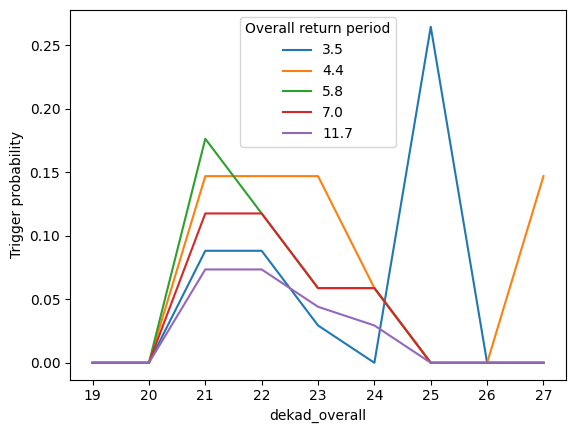

In [914]:
fig, ax = plt.subplots()

for rp, group in df_opt_trigger_probs.groupby("rp"):
    if rp < 3 or rp > 15:
        continue
    group.plot(
        x="dekad_overall", y="trigger_revised", ax=ax, label=f"{rp:.1f}"
    )
ax.legend(title="Overall return period")

ax.set_ylabel("Trigger probability")

<Axes: xlabel='overall_rp'>

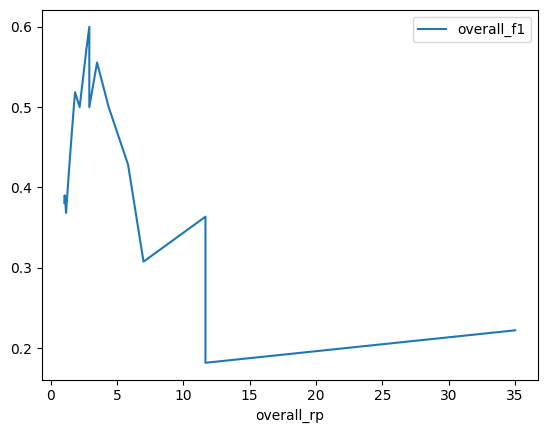

In [932]:
df_opt_metrics.sort_values("overall_rp").plot(x="overall_rp", y="overall_f1")

In [935]:
df_opt_trigger_years["rp"].unique()

array([35.        , 11.66666667,  7.        ,  4.375     ,  5.83333333,
        2.91666667,  3.5       ,  2.69230769,  2.1875    ,  1.84210526,
        1.59090909,  1.75      ,  1.45833333,  1.34615385,  1.2962963 ,
        1.20689655,  1.16666667,  1.06060606,  1.02941176])

In [942]:
rp = 4.375
df_sel_opt_rp = df_opt_trigger_years[
    (df_opt_trigger_years["rp"] == rp)
    & df_opt_trigger_years["trigger_revised"]
]

In [943]:
df_sel_opt_rp

,dekad_overall,year,trigger_revised,rp
1292,21,1991,True,4.375
1293,21,1992,True,4.375
1298,21,1997,True,4.375
1303,21,2002,True,4.375
1315,21,2014,True,4.375
1326,22,1991,True,4.375
1327,22,1992,True,4.375
1332,22,1997,True,4.375
1337,22,2002,True,4.375
1349,22,2014,True,4.375


In [952]:
1991 in df_sel_opt_rp[df_sel_opt_rp["dekad_overall"] == dekad][
    "year"
].to_list()

True

In [963]:
def highlight_true(val):
    if isinstance(val, bool) and val is True:
        return "background-color: crimson"
    return ""

In [969]:
cols = ["year", "Humanitarian Bad Years (rank)", "Amount in US$", "target"]
df_disp = df_stats_iri[df_stats_iri["year"] < 2025][cols]
df_disp = df_disp.sort_values("year", ascending=False)
for dekad in range(19, 27 + 1):
    df_disp[dekad] = df_disp["year"].isin(
        df_sel_opt_rp[df_sel_opt_rp["dekad_overall"] == dekad][
            "year"
        ].to_list()
    )

df_disp.style.map(highlight_true).format(
    {"Humanitarian Bad Years (rank)": "{:.0f}", "Amount in US$": "{:,.0f}"}
)

,year,Humanitarian Bad Years (rank),Amount in US$,target,19,20,21,22,23,24,25,26,27
33,2024,30,0,False,False,False,False,False,False,False,False,False,False
32,2023,30,0,False,False,False,False,False,False,False,False,False,False
31,2022,30,0,False,False,False,False,False,False,False,False,False,False
30,2021,10,0,True,False,False,False,False,False,False,False,False,False
29,2020,16,0,False,False,False,False,False,False,False,False,False,False
28,2019,8,0,True,False,False,False,False,True,False,False,False,True
27,2018,30,0,False,False,False,False,False,False,False,False,False,False
26,2017,6,"3,975,873",True,False,False,False,False,False,False,False,False,False
25,2016,16,0,False,False,False,False,False,False,False,False,False,False
24,2015,12,0,False,False,False,False,False,False,False,False,False,False


In [845]:
df_earliest_dekad_opt = (
    df_opt_trigger_years[df_opt_trigger_years["trigger_revised"]]
    .groupby(["rp", "year"])["dekad_overall"]
    .min()
    .reset_index()
    .groupby("rp")["dekad_overall"]
    .mean()
    .reset_index()
)

<Axes: xlabel='rp'>

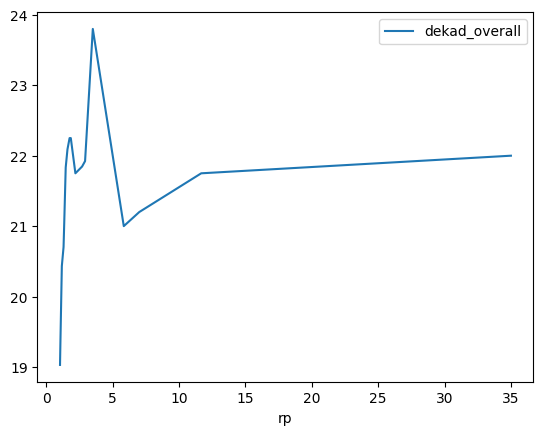

In [846]:
df_earliest_dekad_opt.plot(x="rp", y="dekad_overall")

In [847]:
pred_col = "target_logreg_loocv"

overall_dicts = []

for single_nyears_target in range(1, total_years):
    dicts = []
    for dekad, group in df_dek_compare.groupby("dekad_overall"):
        thresh = group.sort_values(pred_col, ascending=False).iloc[
            single_nyears_target - 1
        ][pred_col]

        group["trigger"] = group[pred_col] >= thresh

        pp = group["trigger"]
        p = group["target"]
        tp = pp & p
        ppv = tp.sum() / pp.sum()

        tpr = tp.sum() / p.sum()
        f1 = 2 * ppv * tpr / (ppv + tpr)

        dicts.append({"dekad": dekad, "f1": f1})
    df_dek_metrics = pd.DataFrame(dicts)

    best_row = df_dek_metrics.loc[df_dek_metrics["f1"].idxmax()]
    best_f1 = best_row["f1"]
    best_dek = best_row["dekad"]

    overall_dicts.append(
        {
            "rp": (total_years + 1) / single_nyears_target,
            "f1": best_f1,
            "dekad": best_dek,
        }
    )

df_bestdek_metrics = pd.DataFrame(overall_dicts)

/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_14715/786468021.py:20: RuntimeWarning: invalid value encountered in scalar divide
  f1 = 2 * ppv * tpr / (ppv + tpr)
/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_14715/786468021.py:20: RuntimeWarning: invalid value encountered in scalar divide
  f1 = 2 * ppv * tpr / (ppv + tpr)
/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_14715/786468021.py:20: RuntimeWarning: invalid value encountered in scalar divide
  f1 = 2 * ppv * tpr / (ppv + tpr)
/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_14715/786468021.py:20: RuntimeWarning: invalid value encountered in scalar divide
  f1 = 2 * ppv * tpr / (ppv + tpr)
/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_14715/786468021.py:20: RuntimeWarning: invalid value encountered in scalar divide
  f1 = 2 * ppv * tpr / (ppv + tpr)
/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_14715/786468021.py:20: RuntimeWarning: invalid value encounte

In [849]:
pred_col = "target_logreg_loocv"

sel_dekad = 27

overall_dicts = []

for single_nyears_target in range(1, total_years):
    dicts = []
    group = df_dek_compare[df_dek_compare["dekad_overall"] == sel_dekad].copy()
    thresh = group.sort_values(pred_col, ascending=False).iloc[
        single_nyears_target - 1
    ][pred_col]

    group["trigger"] = group[pred_col] >= thresh

    pp = group["trigger"]
    p = group["target"]
    tp = pp & p
    ppv = tp.sum() / pp.sum()

    tpr = tp.sum() / p.sum()
    f1 = 2 * ppv * tpr / (ppv + tpr)

    overall_dicts.append(
        {
            "rp": (total_years + 1) / single_nyears_target,
            "f1": f1,
        }
    )

df_singledek_metrics = pd.DataFrame(overall_dicts)

/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_14715/4203225746.py:22: RuntimeWarning: invalid value encountered in scalar divide
  f1 = 2 * ppv * tpr / (ppv + tpr)
/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_14715/4203225746.py:22: RuntimeWarning: invalid value encountered in scalar divide
  f1 = 2 * ppv * tpr / (ppv + tpr)
/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_14715/4203225746.py:22: RuntimeWarning: invalid value encountered in scalar divide
  f1 = 2 * ppv * tpr / (ppv + tpr)


<Axes: xlabel='rp'>

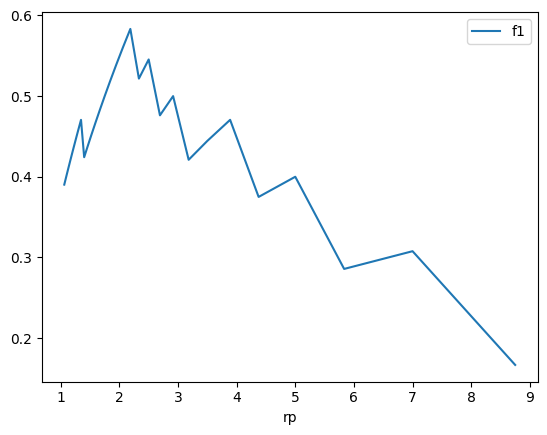

In [850]:
df_singledek_metrics.plot(x="rp", y="f1")

In [921]:
df_opt_metrics_singular = df_opt_metrics.groupby("overall_rp")

,single_nyears_target,best_ppv,overall_rp,overall_f1
0,1,1.000000,35.000000,0.222222
1,2,0.500000,11.666667,0.181818
2,3,0.666667,11.666667,0.363636
3,4,0.500000,7.000000,0.307692
4,5,0.400000,4.375000,0.500000
5,6,0.500000,5.833333,0.428571
6,7,0.428571,2.916667,0.500000
7,8,0.500000,2.916667,0.600000
8,9,0.555556,3.500000,0.555556
9,10,0.500000,2.916667,0.600000


(1.0, 10.0)

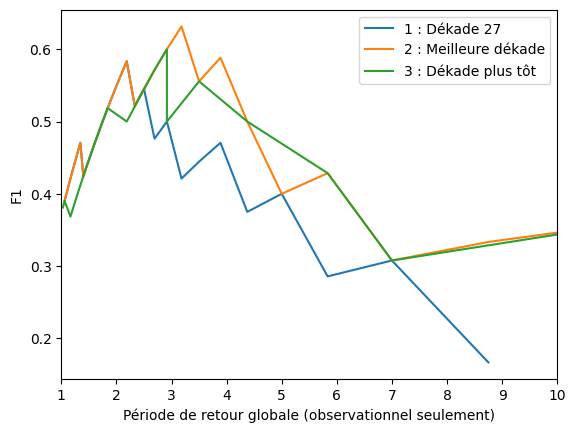

In [920]:
fig, ax = plt.subplots()

df_singledek_metrics.plot(
    x="rp", y="f1", label=f"1 : Dékade {sel_dekad}", ax=ax
)
df_bestdek_metrics.plot(x="rp", y="f1", label="2 : Meilleure dékade", ax=ax)
df_opt_metrics.sort_values("overall_rp").plot(
    x="overall_rp", y="overall_f1", label="3 : Dékade plus tôt", ax=ax
)

ax.set_xlabel("Période de retour globale (observationnel seulement)")

ax.set_ylabel("F1")

ax.set_xlim(1, 10)

(1.0, 10.0)

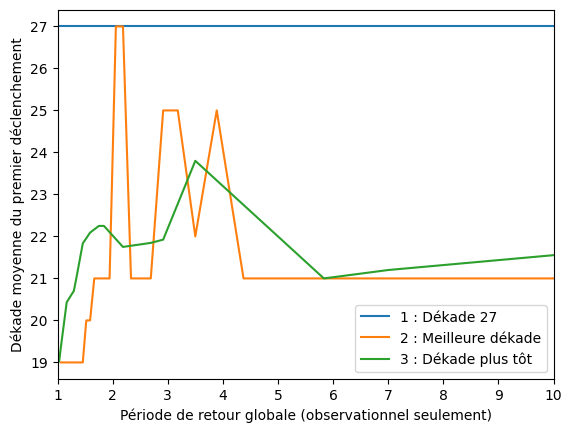

In [931]:
fig, ax = plt.subplots()

ax.plot([0, 100], [27, 27], label=f"1 : Dékade {sel_dekad}")
df_bestdek_metrics.plot(x="rp", y="dekad", label="2 : Meilleure dékade", ax=ax)
df_earliest_dekad_opt.plot(
    x="rp", y="dekad_overall", label="3 : Dékade plus tôt", ax=ax
)
ax.legend()

ax.set_xlabel("Période de retour globale (observationnel seulement)")
ax.set_ylabel("Dékade moyenne du premier déclenchement")

ax.set_xlim(1, 10)

<Axes: xlabel='rp'>

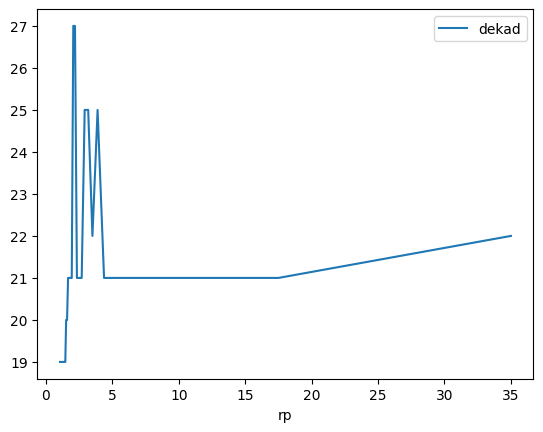

In [853]:
df_bestdek_metrics.plot(x="rp", y="dekad")

<Axes: xlabel='rp'>

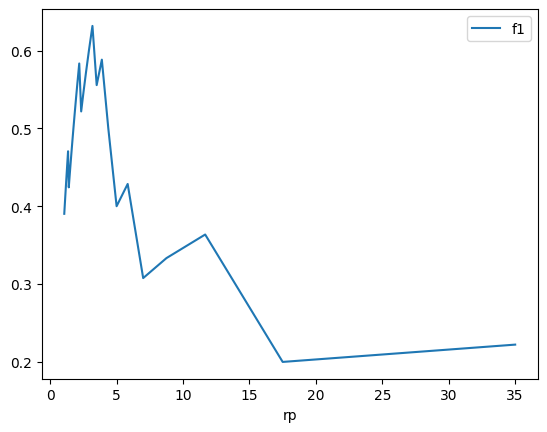

In [854]:
df_bestdek_metrics.plot(x="rp", y="f1")

In [855]:
n_years_overall_target

8

In [856]:
pred_col

'target_logreg_loocv'

In [857]:
ind_norm_all_cols

['rfh_all_cumul_norm', 'asi_all_norm']

In [858]:
for ind_col in ind_norm_all_cols + [pred_col]:
    print(ind_col)

rfh_all_cumul_norm
asi_all_norm
target_logreg_loocv


In [859]:
dicts = []
for ind_col in ind_norm_all_cols + [
    "target_logreg",
    # "target_logreg_loocv",
    # "hum_bad_aligned_norm_reg",
    # "hum_bad_aligned_norm_reg_loocv",
]:
    for dekad, group in df_dek_compare.groupby("dekad_overall"):
        thresh = group.sort_values(ind_col, ascending=False).iloc[
            n_years_overall_target - 1
        ][ind_col]

        group["trigger"] = group[ind_col] >= thresh

        pp = group["trigger"]
        p = group["target"]
        tp = pp & p
        ppv = tp.sum() / pp.sum()
        tpr = tp.sum() / p.sum()

        f1 = 2 * ppv * tpr / (ppv + tpr)
        dicts.append({"ind": ind_col, "dekad": dekad, "f1": f1})

df_dek_metrics = pd.DataFrame(dicts)
df_dek_metrics = df_dek_metrics.sort_values("dekad")

<Axes: xlabel='dekad'>

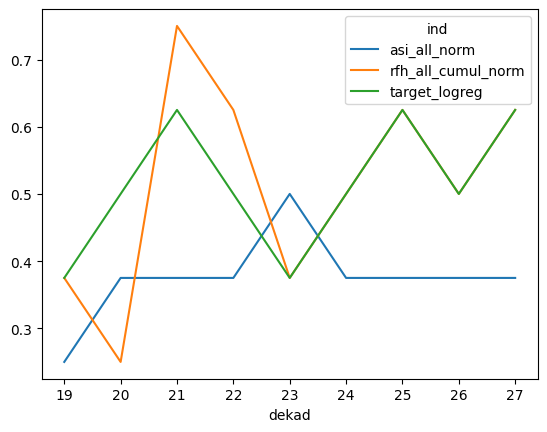

In [860]:
df_dek_metrics.pivot(columns="ind", values="f1", index="dekad").plot()